# **Delivery Performance Optimization:**

> **`Problem`**:   
The company needs to improve its on-time delivery performance to enhance customer satisfaction and competitive advantage.

> **`Business Impact`**:   
Poor delivery performance leads to customer dissatisfaction, negative reviews, and potential loss of business to competitors.

> **`Key Questions`**:     
> 1. What is the current on-time delivery rate across different warehouse blocks?
> 2. Which factors most significantly impact delivery timeliness?
> 3. How can we predict which shipments are likely to be delayed?

In [1]:
import pandas as pd 
import numpy as np 
import warnings as war 
war.filterwarnings(action= "ignore")
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data= pd.read_json("https://raw.githubusercontent.com/rajesh-coventry/Projects/refs/heads/master/02_Data_Visuallization/05_E-Commerce_Shipping/ecommerce_shipping_data.json")
data.shape

(10999, 12)

In [3]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


## **1. Data Exploration and Quality Assessment:**

In [4]:
# Descriptive statistics for numerical columns: 
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Outliers Detection:**

In [5]:
# Outliers Detection and save outliers in series for each column:
outliers = {}
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index

In [6]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [7]:
outliers["ID"], outliers["Customer_rating"], outliers["Customer_care_calls"], outliers["Cost_of_the_Product"], outliers["Weight_in_gms"], outliers["Reached.on.Time_Y.N"]

# These columns have no outlier values

(Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'))

Following two columns `'Prior_purchases'` and, `"Discount_offered"`  contains outlier values:

In [8]:
out1= outliers["Prior_purchases"]
out1= out1.to_frame(name= "out11")
out1.head(3)

,out11
37,37
62,62
74,74


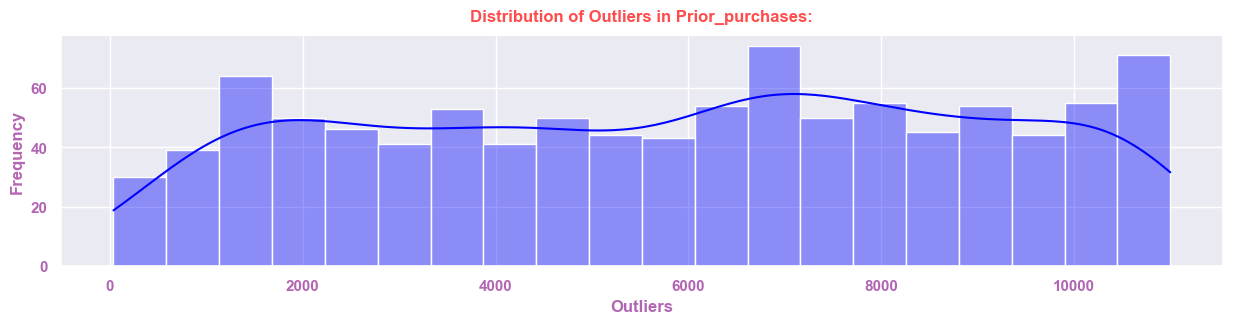

In [9]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out1, x="out11", kde=True, bins=20, color= "blue", alpha=0.4)
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

In [10]:
outliers["Discount_offered"]
out2= outliers["Discount_offered"].to_frame(name= "out22")
out2.head(3)

,out22
0,0
1,1
2,2


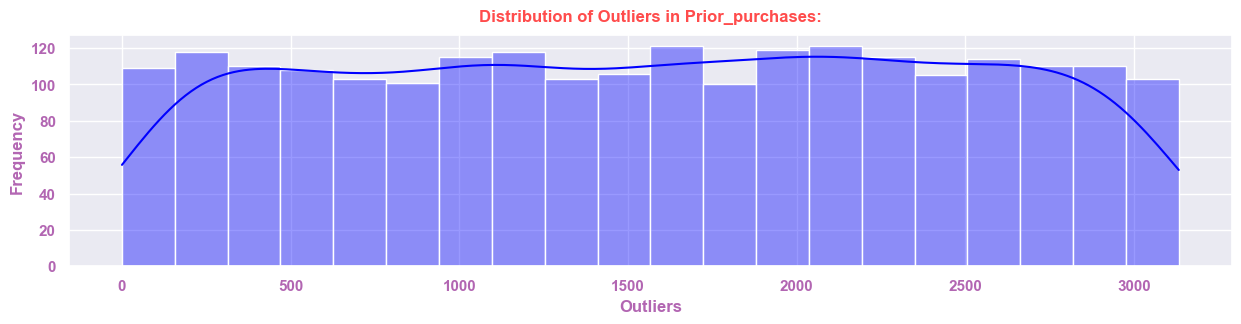

In [11]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out2, x="out22", kde=True, bins=20, alpha= 0.4, color= "blue")
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

**Box plots for the distribution of all numeric columns:**

In [12]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

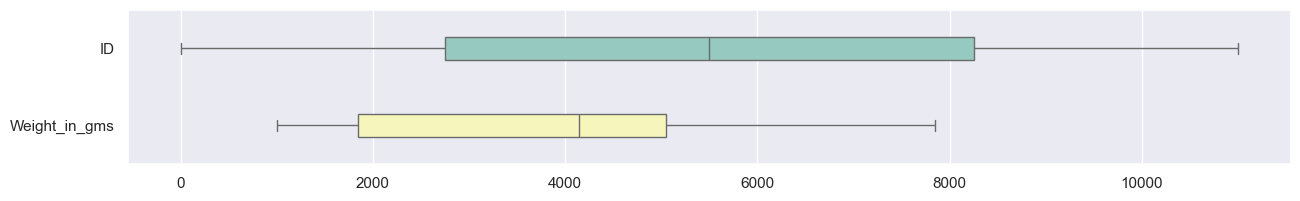

In [13]:
# Box plot for the distribution of all numeric columns:
plt.figure(figsize=(15, 2))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[["ID", "Weight_in_gms"]], orient="h", palette="Set3", width= 0.3)
plt.show()

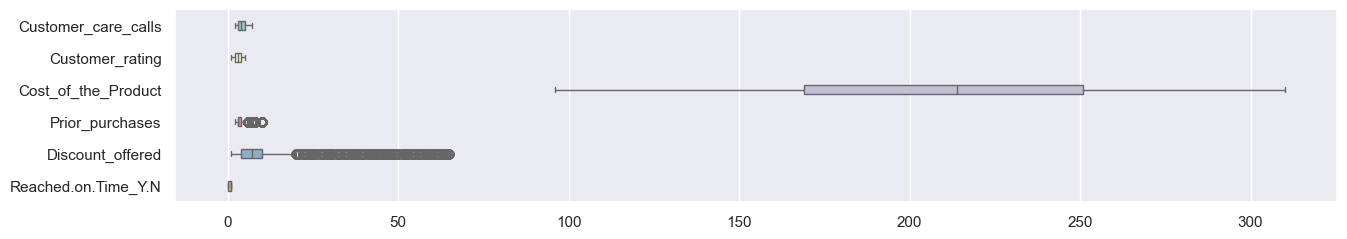

In [14]:
plt.figure(figsize=(15, 2.5))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered',
       'Reached.on.Time_Y.N']], orient="h", palette="Set3", width= 0.3)
plt.show()

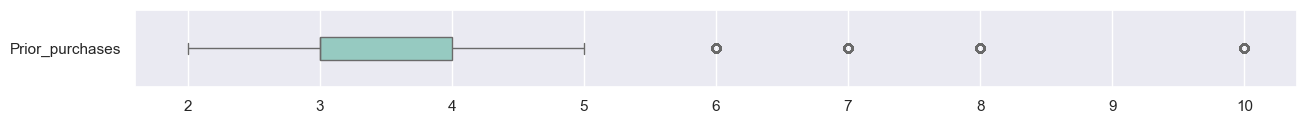

In [15]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Prior_purchases']], orient="h", palette="Set3", width= 0.3)
plt.show()

<Axes: >

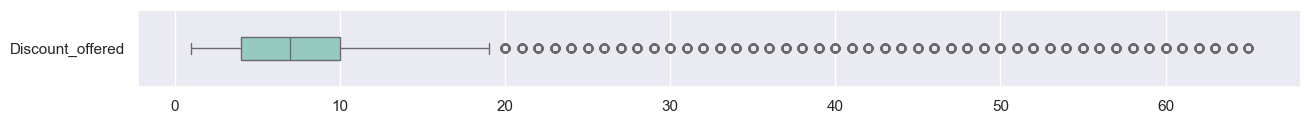

In [16]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Discount_offered']], orient="h", palette="Set3", width= 0.3)

-----
-----
-----
-----
---

## **2. Overall Delivery Performance Baseline:**

In [17]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [18]:
data["Reached.on.Time_Y.N"].value_counts().reset_index()

,Reached.on.Time_Y.N,count
0,1,6563
1,0,4436


In [19]:
current_on_time_delivery_rate= round((data["Reached.on.Time_Y.N"].value_counts().reset_index().loc[0, "count"] / data.shape[0]) * 100, 2)
print(F'Current on-time Delivery Rate is: {current_on_time_delivery_rate}') 

Current on-time Delivery Rate is: 59.67


Current on-time delivery rate is about 60%.

In [20]:
# Summary statistics for on-time deliveries:
data[data["Reached.on.Time_Y.N"]== 1].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.0
mean,4424.978364,3.991467,3.005790,207.289197,3.498095,18.663721,3272.640104,1.0
std,3243.986559,1.122592,1.412692,48.054876,1.517285,19.108797,1576.148391,0.0
min,1.000000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,1.0
25%,1641.500000,3.000000,2.000000,167.000000,3.000000,5.000000,1735.500000,1.0
50%,3467.000000,4.000000,3.000000,209.000000,3.000000,9.000000,3231.000000,1.0
75%,7194.500000,5.000000,4.000000,249.000000,4.000000,32.000000,4696.500000,1.0
max,10995.000000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.0


**Statistics for `on_time_deliveries`:**
* Customers make about 4 customer care calls on average.

* Average customer rating is roughly 3 out of 5.
* Mean product cost is around 207 units.
* Customers typically make 3 to 4 prior purchases.
* Average discount offered is nearly $18.66.
* Products weigh about 3273 grams on average.
* All deliveries reached on time (mean is 1.0).

In [21]:
data.sample(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
7337,7338,F,Ship,3,1,207,4,low,M,9,4252,0
979,980,F,Ship,4,4,140,2,low,F,47,1831,1
9523,9524,F,Ship,3,3,222,4,low,F,6,5284,1
9435,9436,B,Road,6,4,256,4,medium,F,9,1791,0
8711,8712,F,Ship,4,5,223,3,low,M,9,5649,1
1455,1456,B,Ship,4,5,241,4,medium,M,58,2874,1
3357,3358,B,Ship,3,3,211,6,low,M,5,5777,1
308,309,A,Ship,4,2,165,2,high,M,11,1596,1
1255,1256,F,Ship,4,5,196,3,medium,M,16,3722,1
4820,4821,A,Ship,6,3,247,4,low,M,3,1616,1


In [22]:
# Summary statistics for off-time deliveries:
data[data["Reached.on.Time_Y.N"]== 0].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.0
mean,7090.479486,4.147656,2.967989,214.498647,3.670424,5.545987,4168.668395,0.0
std,2278.543555,1.162771,1.414808,47.757432,1.525444,2.877727,1573.954178,0.0
min,3136.000000,2.000000,1.000000,97.000000,2.000000,1.000000,1001.000000,0.0
25%,5092.250000,3.000000,2.000000,174.000000,3.000000,3.000000,4043.500000,0.0
50%,7096.000000,4.000000,3.000000,222.000000,3.000000,6.000000,4674.000000,0.0
75%,9078.500000,5.000000,4.000000,254.000000,4.000000,8.000000,5337.000000,0.0
max,10999.000000,7.000000,5.000000,310.000000,10.000000,10.000000,6000.000000,0.0


**Statistics for `not_on_time_deliveries`:**

* Customers made about 4.15 calls on average.

* Average customer rating is approximately 3 out of 5.
* Product cost averages around 214 units.
* Customers made nearly 3.7 prior purchases.
* Average discount offered is about $5.5.
* Product weight averages around 4169 grams.

----
---
---
---
----
----
---

## **3. Warehouse Block Performance Analysis:**

In [23]:
data.columns 

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [24]:
# Warehouse and shipments from each of the house:
nan= data["Warehouse_block"].value_counts()
nan

Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

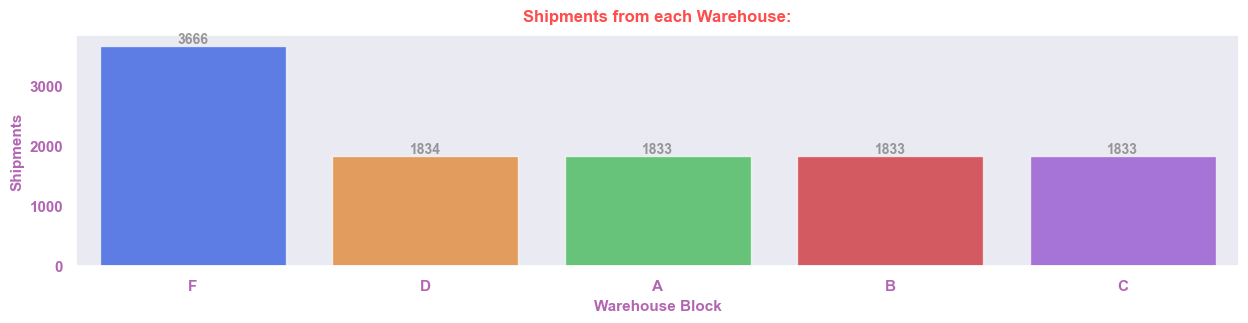

In [25]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= nan.index, y= nan.values, palette="bright", alpha= 0.7)
plt.title("Shipments from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7) 
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11) 
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
# add annotations to the bars
for i, v in enumerate(nan.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontweight='bold', fontsize= 10, color="gray", alpha=0.8)
plt.show()

In [26]:
rat= data.groupby("Warehouse_block")["Reached.on.Time_Y.N"].value_counts().reset_index(name= "count")
rat

,Warehouse_block,Reached.on.Time_Y.N,count
0,A,1,1075
1,A,0,758
2,B,1,1104
3,B,0,729
4,C,1,1094
5,C,0,739
6,D,1,1096
7,D,0,738
8,F,1,2194
9,F,0,1472


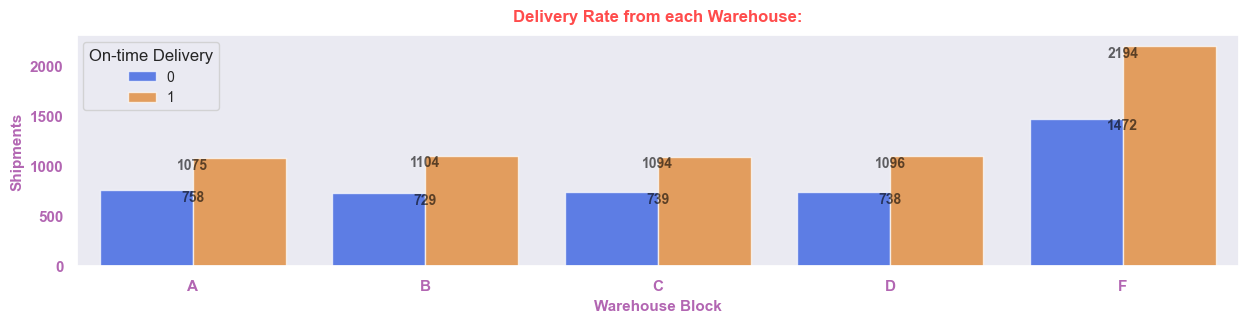

In [27]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= rat["Warehouse_block"], y= rat["count"], hue= rat["Reached.on.Time_Y.N"], palette="bright", alpha= 0.7)
plt.title("Delivery Rate from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.legend(title= "On-time Delivery", loc= "upper left", fontsize= 10)

# Add annotations for each bar group
for i in range(len(rat["Warehouse_block"].unique())):
    for j in range(len(rat["Reached.on.Time_Y.N"].unique())):
        index = i * len(rat["Reached.on.Time_Y.N"].unique()) + j
        value = rat.iloc[index]["count"]
        plt.text(i, value, str(value), ha='center', va='top', fontweight='bold', fontsize=10, color="black", alpha=0.6)

plt.show()

In [28]:
# compute the propersion of on-time deliveries for each warehouse block
rat["proportion"] = rat.groupby("Warehouse_block")["count"].transform(lambda x: x / x.sum())

In [29]:
rat

,Warehouse_block,Reached.on.Time_Y.N,count,proportion
0,A,1,1075,0.586470
1,A,0,758,0.413530
2,B,1,1104,0.602291
3,B,0,729,0.397709
4,C,1,1094,0.596836
5,C,0,739,0.403164
6,D,1,1096,0.597601
7,D,0,738,0.402399
8,F,1,2194,0.598472
9,F,0,1472,0.401528


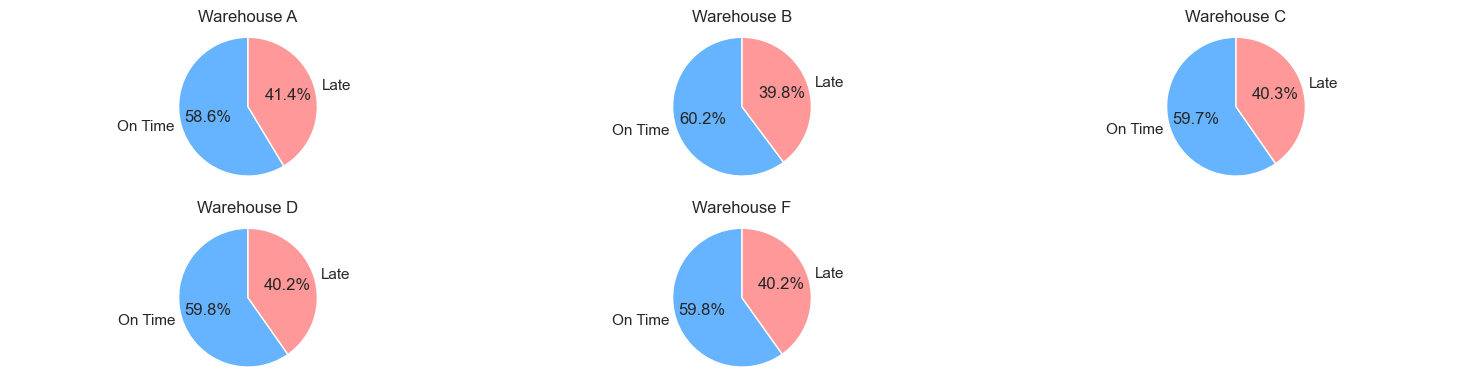

In [30]:
import math 
# Get unique warehouses
warehouses = rat['Warehouse_block'].unique()
n_warehouses = len(warehouses)

# Subplot grid dimensions
n_cols = 3
n_rows = math.ceil(n_warehouses / n_cols)

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2))
axes = axes.flatten()  # Flatten in case of single row

# Loop through each warehouse and plot
for i, block in enumerate(warehouses):
    subset = rat[rat['Warehouse_block'] == block]
    sizes = subset['count'].values
    labels = ['On Time', 'Late']
    colors = ['#66b3ff', '#ff9999']

    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Warehouse {block}')
    axes[i].axis('equal')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

* **`Warehouse A`**: 58.6% deliveries were on time, 41.4% were late

* **`Warehouse B`**: Has the highest on-time rate at 60.2%
* **`Warehouse C`**: 59.7% on-time; slightly better than Warehouse A
* **`Warehouse D`**: Same on-time rate as Warehouse C at 59.8%
* **`Warehouse F`**: Also 59.8% on-time, equal to Warehouse D
* **`All warehouses`**: On-time delivery rate is consistently around 59–60%
* **`Late deliveries`**: Range from 39.8% to 41.4% across all warehouses
* **`Warehouse A`**: Has the highest late delivery rate among all
* **`Warehouse B`**: Most efficient in terms of timely deliveries

**Statistical significance tests to identify meaningful differences between warehouses:**

To statistically compare the delivery performance between **`warehouses`** (based on on-time vs. late deliveries), we can treat this as a **`test of proportions`** or a **`chi-squared test`** for categorical data.

If we want to check if the **proportion of on-time deliveries differs significantly** between warehouses then;

   * **Null Hypothesis $(H₀)$:**
     The proportion of on-time deliveries is the **same** in Warehouse A and Warehouse B.

   * **Alternative Hypothesis $(H₁)$:**
    The proportion of on-time deliveries is **different** between Warehouse A and Warehouse B.

We use:
* **`Chi-Square Test of Independence`** for all warehouses at once.

* **`Two-proportion z-test`** for pairwise comparisons.

In [31]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

**Pivot for Chi-Square Test:**

In [32]:
pivot = rat.pivot(index='Warehouse_block', columns='Reached.on.Time_Y.N', values='count')
pivot.columns = ['Late', 'OnTime']  # 0 = Late, 1 = OnTime
pivot = pivot[['OnTime', 'Late']]  # reorder
pivot

,OnTime,Late
Warehouse_block,,
A,1075,758
B,1104,729
C,1094,739
D,1096,738
F,2194,1472


**Chi-Square Test (all warehouses):**

In [33]:
chi2, p, dof, expected = chi2_contingency(pivot.values)

print(f"Chi-squared Test Statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Reject the null hypothesis: Significant differences exist between warehouses.")
else:
    print("Fail to reject the null: No significant differences between warehouses.")

Chi-squared Test Statistic: 1.0894
p-value: 0.8960
Fail to reject the null: No significant differences between warehouses.


> Even though we have slight difference in proportion for `on-time` deliveries for different warehouses, statistical test suggests that there is no significant difference between the `on_time_deliveries` between warehouses and the small differences observed are due to random nature of the process. 

**Pairwise Proportion Z-tests (optional, for deeper insight):**

`Example`: A vs B:

In [34]:
# On-time counts
success = np.array([1075, 1104])
# Total deliveries
nobs = np.array([1075+758, 1104+729])

stat, pval = proportions_ztest(success, nobs)
print(f"Proportion z-test A vs B: p-value = {pval:.4f}")

Proportion z-test A vs B: p-value = 0.3293


> Fail to reject null hypothesis $(H_0)$ and so there is no significant difference between `proportions of on_time_deliveris` between warehouse A and B.

`Example`: B vs F:

In [35]:
pivot

,OnTime,Late
Warehouse_block,,
A,1075,758
B,1104,729
C,1094,739
D,1096,738
F,2194,1472


In [36]:
# On-time counts
success = np.array([1104, 2194])
# Total deliveries
nobs = np.array([1104+729, 2194+1472])

stat, pval = proportions_ztest(success, nobs)
print(f"Proportion z-test B vs F: p-value = {pval:.4f}")

Proportion z-test B vs F: p-value = 0.7853


> Fail to reject null hypothesis ($H_0$) and so there is no significant difference between `proportions of on time deliveris` between warehouse B and F.

**Decision Criteria:** 

> * **$p < 0.05$** → Significant difference (reject H₀)
> * **$p ≥ 0.05$** → No significant difference (fail to reject H₀)

Since, from calculations, difference between warehous B and F was largest among all the warehouses and statistical test suggests these differences just randomness; overall, proportion `on_time_delivery` for all warehouses is same.

----
-----
-----
-----
----

## **4. Shipping Mode Effectiveness Analysis:**

In [37]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [38]:
data["Mode_of_Shipment"].nunique()

3

In [39]:
data["Mode_of_Shipment"].unique()

array(['Flight', 'Ship', 'Road'], dtype=object)

In [40]:
prop_of_mode_of_ship= data["Mode_of_Shipment"].value_counts(normalize=True).reset_index(name= "proportion")
prop_of_mode_of_ship

,Mode_of_Shipment,proportion
0,Ship,0.678425
1,Flight,0.161560
2,Road,0.160015


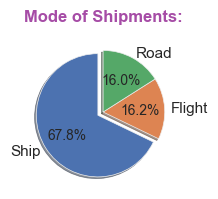

In [41]:
plt.figure(figsize=(2, 2))
# set theme for matplotlib plot using matplotlib
plt.style.use("ggplot") 
plt.pie(x= prop_of_mode_of_ship["proportion"], labels= prop_of_mode_of_ship["Mode_of_Shipment"], autopct= "%1.1f%%", shadow= True, startangle= 90, explode= (0.1, 0, 0), colors= sns.color_palette("deep"))
plt.title("Mode of Shipments:", fontsize= 12, fontweight= "bold", color= "purple", pad= 10, alpha= 0.7)
plt.show()

* Ship accounts for the majority at 67.8%.

* Flight makes up 16.2% of shipments.
* Road accounts for 16.0% of shipments.
* Shipments by ship are significantly more common.
* Road and flight shipments have nearly equal shares.
* Flight has a slightly larger share than road.

#### **`Hypothesis Test`:** *To Test if Shipments by ship are significantly higher or not:*

We want to test whether the proportion of **Ship shipments** is significantly greater than the **average of others**.

Let:

* $p_{ship}$ = proportion of shipments by ship
* $p_{others}$ = average proportion of shipments by road and flight

**Null Hypothesis (H₀):** $p_{ship} \leq p_{others}$ : (Shipments by ship are not significantly higher)

**Alternative Hypothesis:** (H₁): $p_{ship} > p_{others}$: (Shipments by ship are significantly higher)

Since we're comparing one proportion against a reference proportion (others combined), use a **one-sample Z-test for proportion**.

**The test statistic is:**

$$
Z = \frac{p_{ship} - p_0}{\sqrt{\frac{p_0 (1 - p_0)}{n}}}
$$

Where:

* $p_{ship} = 0.678$
* $p_0 = \frac{0.160 + 0.162}{2} = 0.161$
* $n$ = total sample size (need this to compute standard error)

In [42]:
data.shape[0]

10999

In [43]:
from statsmodels.stats.proportion import proportions_ztest

# Observed count for ship
count = 7455          # Ship count
nobs = 10999          # Total shipments

# Hypothesized proportion (average of road and flight)
p_null = (0.160 + 0.162) / 2

# Perform one-sample z-test for proportion
stat, pval = proportions_ztest(count, nobs, value=p_null, alternative='larger')

print(f"Z-statistic: {stat:.2f}, p-value: {pval:.20f}")

Z-statistic: 115.98, p-value: 0.00000000000000000000


> **Decision Rule:**
> 
> * If **p-value < α (e.g., 0.05)** → reject H₀ → shipment by ship is **significantly higher**
> * If **p-value ≥ α** → fail to reject H₀ → no significant evidence

> There is a significant evidence to `Reject Null Hypothesis` and we conclude that; `Shipments by Ship are significantly higher than the other modes.`  

In [44]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


**Find out the overall contribution in shipping by each of the shipping approach:**

In [45]:
number_shipments= data.shape[0]
# Contribution on total shipment by each shipping approach: 
prop_of_ships_by_flight= (data[data["Mode_of_Shipment"]== "Flight"].shape[0])/ number_shipments * 100
prop_of_ships_by_road=  (data[data["Mode_of_Shipment"]== "Road"].shape[0])/number_shipments * 100
prop_of_ships_by_ocean= (data[data["Mode_of_Shipment"]== "Ship"].shape[0])/number_shipments * 100
prop_series= pd.Series([prop_of_ships_by_flight, prop_of_ships_by_road, prop_of_ships_by_ocean], index= ["Flight", "Road", "Ship"]).T
prop_series

Flight    16.156014
Road      16.001455
Ship      67.842531
dtype: float64

In [46]:
sns.color_palette(as_cmap=True)

['#E24A33', '#348ABD', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#FFB5B8']

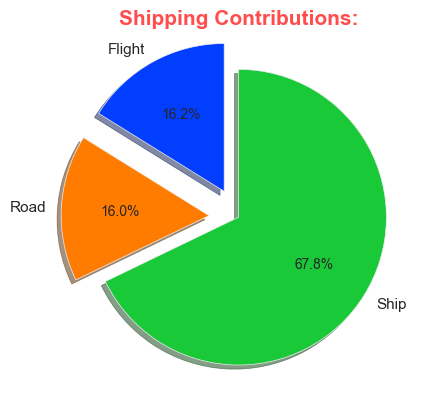

In [47]:
plt.pie(x= prop_series, labels= prop_series.index, autopct= "%1.1f%%", shadow= True, explode= (0.2, 0.2, 0), startangle= 90, colors= sns.color_palette("bright"))
plt.title("Shipping Contributions:", color= "Red", alpha= 0.7, fontweight= "bold", fontsize= 15)
plt.show()

In [48]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [49]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [50]:
ot_mos= data.groupby("Mode_of_Shipment")["Reached.on.Time_Y.N"].value_counts(normalize=True).reset_index()
ot_mos

,Mode_of_Shipment,Reached.on.Time_Y.N,proportion
0,Flight,1,0.601576
1,Flight,0,0.398424
2,Road,1,0.588068
3,Road,0,0.411932
4,Ship,1,0.597561
5,Ship,0,0.402439


In [51]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

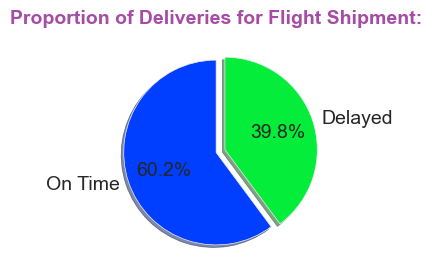

In [52]:
plt.figure(figsize=(3, 3))
plt.style.use("seaborn-v0_8-bright")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Flight"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Flight Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

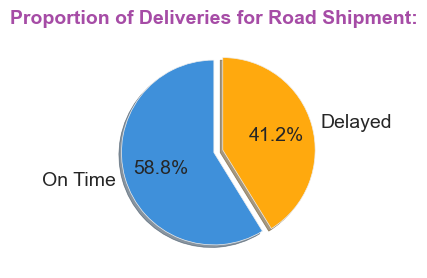

In [53]:
plt.figure(figsize=(3, 3))
plt.style.use("petroff10")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Road"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Road Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

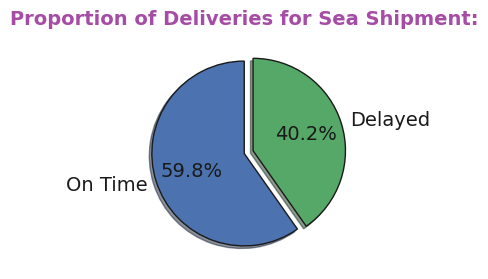

In [54]:
plt.figure(figsize=(3, 3))
plt.style.use("classic")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Ship"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Sea Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

In [55]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [56]:
# Group by 'Mode_of_Shipment' and calculate on-time rates
on_time_rates = data.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean().reset_index()
on_time_rates.rename(columns={'Reached.on.Time_Y.N': 'On_Time_Rate'}, inplace=True)
on_time_rates

,Mode_of_Shipment,On_Time_Rate
0,Flight,0.601576
1,Road,0.588068
2,Ship,0.597561


In [57]:
# Calculate average 'Cost_of_the_Product' for each shipping mode
avg_cost = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index()
avg_cost.rename(columns={'Cost_of_the_Product': 'Avg_Cost_of_Product'}, inplace=True)
avg_cost

,Mode_of_Shipment,Avg_Cost_of_Product
0,Flight,209.306697
1,Road,210.475568
2,Ship,210.343072


In [58]:
# Merge for combined view
summary = pd.merge(on_time_rates, avg_cost, on='Mode_of_Shipment')
summary

,Mode_of_Shipment,On_Time_Rate,Avg_Cost_of_Product
0,Flight,0.601576,209.306697
1,Road,0.588068,210.475568
2,Ship,0.597561,210.343072


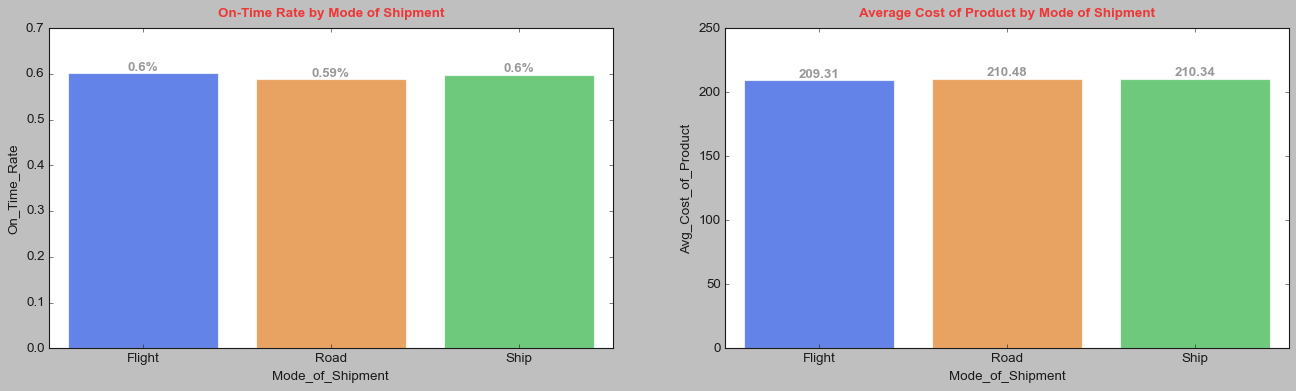

In [59]:
war.filterwarnings(action= "ignore")
# Visualize: Barplot for on-time rate and average cost
fig, ax1 = plt.subplots(1, 2, figsize=(20, 5))
sns.set_theme(context="notebook", style="darkgrid")  # Set the style
# Barplot for on-time rate
sns.barplot(data= summary, x= "Mode_of_Shipment", y= "On_Time_Rate", palette="bright", alpha= 0.7, ax= ax1[0])
# add annotations to the bars
for i, v in enumerate(summary["On_Time_Rate"]):
    ax1[0].text(i, v, f'{round(v, 2)}%', ha='center', va='bottom', fontweight='bold', fontsize= 12, color="gray", alpha=0.8)  

ax1[0].set_title("On-Time Rate by Mode of Shipment", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)

# Visualising on-time rate and average cost
sns.barplot(data= summary, y= "Avg_Cost_of_Product", x= "Mode_of_Shipment", palette="bright", alpha= 0.7, ax= ax1[1])
ax1[1].set_title("Average Cost of Product by Mode of Shipment", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
# Add annotations to the bars
for i, v in enumerate(summary["Avg_Cost_of_Product"]):
    ax1[1].text(i, v, f'{round(v, 2)}', ha='center', va='bottom', fontweight='bold', fontsize= 12, color="gray", alpha=0.8) 

plt.show()

#### **`Hypothesis Test`: Which shipping Mode is cost effective:**

Test if **Flight**, **Road**, or **Ship** has a significantly **lower average cost** than others.

From the table `summary`, **`Flight`** has the lowest average cost, so we will test whether it's significantly lower than the others.

We'll use **`two-sample t-tests`** to compare average cost of **`Flight`** vs each of the others:

**1. `Hypothesis`: Flight vs Road:**

* **H₀**: $\mu_{Flight} \geq \mu_{Road}$
* **H₁**: $\mu_{Flight} < \mu_{Road}$ (Flight is cheaper)

**2. `Hypothesis`: Flight vs Ship:**

* **H₀**: $\mu_{Flight} \geq \mu_{Ship}$
* **H₁**: $\mu_{Flight} < \mu_{Ship}$ (Flight is cheaper)

In [60]:
number_shipments

10999

In [61]:
from scipy.stats import ttest_ind

# Hypothetical samples of product costs: 
flight_costs = data[data["Mode_of_Shipment"]== "Flight"]["Cost_of_the_Product"]
road_costs = data[data["Mode_of_Shipment"]== "Road"]["Cost_of_the_Product"]
ship_costs = data[data["Mode_of_Shipment"]== "Ship"]["Cost_of_the_Product"]

# t-test: one-sided, Flight < Road
t_stat1, p_val1 = ttest_ind(flight_costs, road_costs, alternative='less')

# t-test: one-sided, Flight < Ship
t_stat2, p_val2 = ttest_ind(flight_costs, ship_costs, alternative='less')

print(f"Flight vs Road: p-value = {p_val1:.4f}")
print(f"Flight vs Ship: p-value = {p_val2:.4f}")

Flight vs Road: p-value = 0.2341
Flight vs Ship: p-value = 0.2074


> **Interpretation:** 
> 
> * If p-value < 0.05 → Flight is significantly cheaper.
> * If p-value ≥ 0.05 → No significant cost difference.

Based on means, there is no enough evidence to reject Null Hypothesis. So, there is no significant difference in the cost of shipments by air or road or by bus.

----
---
----
---
-----

## **5. Product Characteristic Impact Analysis:**

> `Examine how product-related factors (importance, weight, cost) influence delivery performance.`   

In [62]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [63]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


**Product Specific factors:** `Product_importance`, `Weight_in_gms`, `Cost_of_the_Product` and, `Discount_offered`. We will study one by one relation of these variables with `delivery` factor.

In [64]:
data["Product_importance"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [65]:
data["Reached.on.Time_Y.N"].unique()

array([1, 0])

In [66]:
apt= data.groupby(by= "Product_importance")["Reached.on.Time_Y.N"].value_counts(normalize=True).reset_index(name= "count").round(4)
apt

,Product_importance,Reached.on.Time_Y.N,count
0,high,1,0.6498
1,high,0,0.3502
2,low,1,0.5928
3,low,0,0.4072
4,medium,1,0.5905
5,medium,0,0.4095


In [67]:
apt[apt["Product_importance"]== "high"]["Reached.on.Time_Y.N"]

0    1
1    0
Name: Reached.on.Time_Y.N, dtype: int64

Text(0.5, 1.0, 'Low Importance Products:')

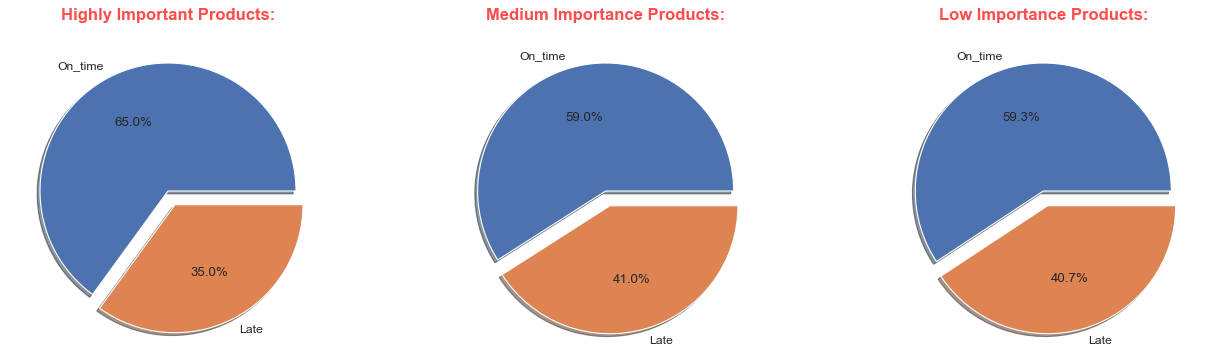

In [68]:
plt.style.use("seaborn-v0_8-darkgrid")
# create three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()
# plot the first subplot
axes[0].pie(x= apt[apt["Product_importance"]== "high"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[0].set_title("Highly Important Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)

axes[1].pie(x= apt[apt["Product_importance"]== "medium"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[1].set_title("Medium Importance Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)

axes[2].pie(x= apt[apt["Product_importance"]== "low"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[2].set_title("Low Importance Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)


**Study the relation between the weight of the product and on-time-delivery or not:**

In [69]:
data["Reached.on.Time_Y.N"].value_counts().reset_index()

,Reached.on.Time_Y.N,count
0,1,6563
1,0,4436


In [70]:
data["Reached.on.Time_Y.N"].dtype

dtype('int64')

In [71]:
data["Weight_in_gms"].dtype

dtype('int64')

In [72]:
data[["Weight_in_gms", "Reached.on.Time_Y.N"]].head(4)

,Weight_in_gms,Reached.on.Time_Y.N
0,1233,1
1,3088,1
2,3374,1
3,1177,1


In [73]:
a= data.groupby(by= "Reached.on.Time_Y.N")["Weight_in_gms"].mean().reset_index()
a

,Reached.on.Time_Y.N,Weight_in_gms
0,0,4168.668395
1,1,3272.640104


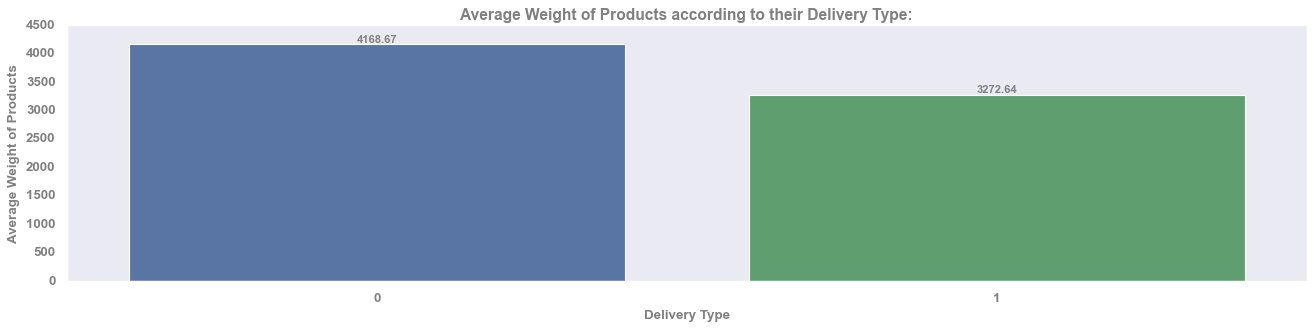

In [74]:
plt.figure(figsize=(20, 4))
sns.set_theme(context="notebook", style="dark")
sns.barplot(data= a, x= "Reached.on.Time_Y.N", y= "Weight_in_gms", palette= "deep6", )
plt.title("Average Weight of Products according to their Delivery Type:", color= "gray", fontsize= 14, fontweight= "bold")
plt.xlabel("Delivery Type", color= "gray", fontsize= 12, fontweight= "bold")    
plt.ylabel("Average Weight of Products", color= "gray", fontsize= 12, fontweight= "bold" )
plt.xticks(color= "gray", fontsize= 12, fontweight= "bold")
plt.yticks(color= "gray", fontsize= 12, fontweight= "bold")
# Add annotations to the bars
for i, v in enumerate(a["Weight_in_gms"]):
    plt.text(i, v, round((v), 2), ha='center', va='bottom', fontweight='bold', fontsize= 10, color="gray", alpha=0.99)  
plt.show()

In [75]:
a

,Reached.on.Time_Y.N,Weight_in_gms
0,0,4168.668395
1,1,3272.640104


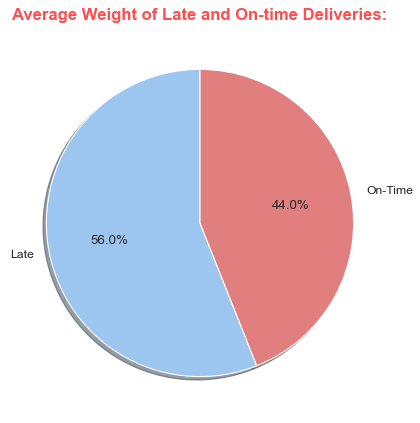

In [76]:
plt.pie(x= a["Weight_in_gms"], normalize=True, labels= ["Late", "On-Time"], autopct= "%1.1f%%", shadow= True, startangle= 90, colors= ["#9cc5ef", "#e17f7f"]) 
plt.title("Average Weight of Late and On-time Deliveries:", fontsize=15, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

* Late deliveries account for **`56%`** of the average delivery weight.

* On-time deliveries contribute **`44%`** of the average delivery weight.
* Late deliveries tend to carry **`heavier loads`** than on-time ones.
* There is a noticeable **`weight disparity`** between late and on-time deliveries.
* Delivery timing appears to be **`linked with shipment weight`**.

#### **Hypothesis Test: To Check the Dependence of Delivery Timing and Shipment Weight:**

In [77]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

We will perform a **Welch’s t-test** here.

* **Null Hypothesis $(H₀)$:** There is **`no significant difference`** in shipment weights between late and on-time deliveries.

* **Alternative Hypothesis $(H₁)$:** There **`is a significant difference`** in shipment weights between late and on-time deliveries.

In [78]:
import pandas as pd
from scipy.stats import ttest_ind

# Separate weights by delivery status
late_weights = data[data['Reached.on.Time_Y.N'] == 0]['Weight_in_gms']
on_time_weights = data[data['Reached.on.Time_Y.N'] == 1]['Weight_in_gms']

# Perform Welch’s t-test (assumes unequal variances)
t_stat, p_value = ttest_ind(late_weights, on_time_weights, equal_var=False)

# Print results
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

#Average weights for deliveries: 
print("Late delivery average weight:", late_weights.mean())
print("On-time delivery average weight:", on_time_weights.mean())

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Shipment weight significantly affects delivery timing.")
else:
    print("Fail to reject H₀: No evidence that weight affects delivery timing.")

T-statistic: 29.2722
P-value: 0.0000
Late delivery average weight: 4168.668394950406
On-time delivery average weight: 3272.6401036111533
Reject H₀: Shipment weight significantly affects delivery timing.


We collect sufficient evidences to reject Null-Hypothesis. So, Shipment weights significantly affects delivery timing. And, products with an average weight greater or equalts to 4168 gms have high chances of having late deliveries.

**Correlation Analysis:**

**Implementation approach**:   
Create correlation analysis between product features and delivery success, use box plots to show delivery rates by product importance levels, and analyze weight distribution impact using scatter plots and correlation matrices.  

In [79]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**Product Specific factors:**   
1. `Product_importance`, 

2. `Weight_in_gms`, 
3. `Cost_of_the_Product`, 
4. `Discount_offered` and, 
5. `Reached.on.Time_Y.N`

In [83]:
b= data[["Product_importance", "Weight_in_gms", "Cost_of_the_Product", "Discount_offered", "Reached.on.Time_Y.N"]]
b.head(3)

,Product_importance,Weight_in_gms,Cost_of_the_Product,Discount_offered,Reached.on.Time_Y.N
0,low,1233,177,44,1
1,low,3088,216,59,1
2,low,3374,183,48,1


In [88]:
co= b.select_dtypes(include= ["int32", "int64", "float32", "float64"]).corr(method= "spearman")
co

,Weight_in_gms,Cost_of_the_Product,Discount_offered,Reached.on.Time_Y.N
Weight_in_gms,1.000000,-0.131980,-0.315677,-0.265958
Cost_of_the_Product,-0.131980,1.000000,-0.115817,-0.071850
Discount_offered,-0.315677,-0.115817,1.000000,0.335108
Reached.on.Time_Y.N,-0.265958,-0.071850,0.335108,1.000000


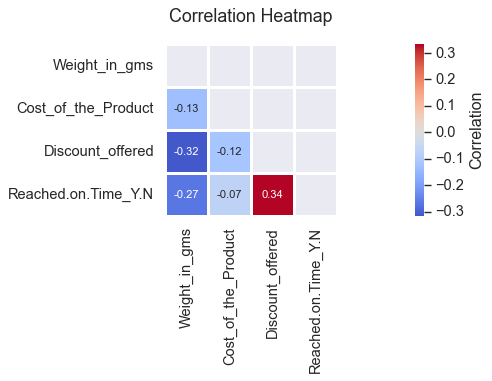

In [103]:
plt.figure(figsize=(20, 5))
sns.set_theme(style="dark", font_scale=1.2)
sns.heatmap(data=co,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation'},
            annot_kws={'size': 10},
            mask=np.triu(np.ones_like(co, dtype=bool)))
plt.title('Correlation Heatmap', pad=20, fontsize=16)
plt.tight_layout()

* **Weight vs Cost:** Weak negative correlation, -0.13.

* **Weight vs Discount:** Moderate negative correlation, -0.32.
* **Weight vs Delivery Time:** Moderate negative correlation, -0.27.
* **Cost vs Discount:** Weak negative correlation, -0.12.
* **Cost vs Delivery Time:** Very weak negative correlation, -0.07.
* **Discount vs Delivery Time:** Moderate positive correlation, 0.34.
* **Weight correlates most with delivery time and discount.**
* **Discount positively impacts on-time delivery likelihood.**

**Delivery Rate by Products Importance Levels:**

In [104]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [105]:
data["Product_importance"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [109]:
c= data.groupby(by= "Product_importance")["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index()
c

,Product_importance,Reached.on.Time_Y.N,proportion
0,high,1,0.649789
1,high,0,0.350211
2,low,1,0.592788
3,low,0,0.407212
4,medium,1,0.590450
5,medium,0,0.409550


Text(0.5, 1.0, 'On-Time Deliveries for High Product Importance:')

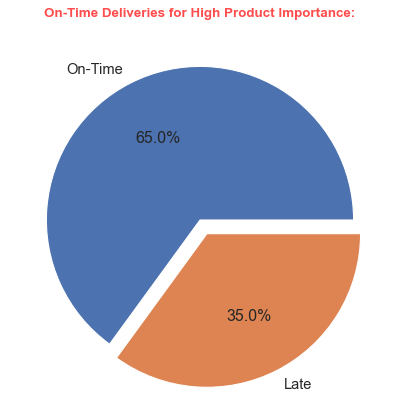

In [116]:
plt.pie(x= c[c["Product_importance"]== "high"]["proportion"], explode= [0, 0.1], autopct= "%1.1f%%",labels= ["On-Time", "Late"] )
plt.title("On-Time Deliveries for High Product Importance:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)